# Playground S5E9 – BPM Prediction · Task 1
Data preparation, cleaning, EDA and feature engineering. Metric: RMSE.

## 1. Load data

In [1]:
import os, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from PIL import Image
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
SEED, TARGET = 42, "BeatsPerMinute"
os.makedirs("eda_visuals", exist_ok=True)
DATA_DIR = next(p for p in [".", "data", "/kaggle/input/playground-series-s5e9", "/mnt/user-data/uploads"]
                if os.path.exists(f"{p}/train.csv"))
train = pd.read_csv(f"{DATA_DIR}/train.csv")
test = pd.read_csv(f"{DATA_DIR}/test.csv")
FEATS = [c for c in test.columns if c != "id"]
def savefig(name):
    plt.tight_layout()
    path = f"eda_visuals/{name}.png"
    plt.savefig(path, dpi=75)
    Image.open(path).convert("P", palette=Image.ADAPTIVE, colors=64).save(path, optimize=True)
    plt.show(); plt.close()
print("train:", train.shape, "| test:", test.shape)
print("features:", FEATS)

train: (524164, 11) | test: (174722, 10)
features: ['RhythmScore', 'AudioLoudness', 'VocalContent', 'AcousticQuality', 'InstrumentalScore', 'LivePerformanceLikelihood', 'MoodScore', 'TrackDurationMs', 'Energy']


## 2. Missing values, duplicates and outliers

In [2]:
cols = FEATS + [TARGET]
print("missing values  train/test:", int(train.isna().sum().sum()), "/", int(test.isna().sum().sum()))
print("duplicate rows (ignoring id):", int(train.drop(columns="id").duplicated().sum()))
print(train[cols].describe().T[["min", "mean", "std", "max"]].round(3))
q1, q3 = train[cols].quantile(.25), train[cols].quantile(.75)
iqr = q3 - q1
pct_out = ((train[cols] < q1 - 1.5*iqr) | (train[cols] > q3 + 1.5*iqr)).mean().mul(100).round(2)
print("\n% of rows outside 1.5*IQR fences:\n", pct_out.to_string())
print("\ntest values outside train range:",
      {c: int(((test[c] < train[c].min()) | (test[c] > train[c].max())).sum()) for c in FEATS})

missing values  train/test: 0 / 0
duplicate rows (ignoring id): 0
                                 min        mean        std         max
RhythmScore                    0.077       0.633      0.157       0.975
AudioLoudness                -27.510      -8.379      4.616      -1.357
VocalContent                   0.024       0.074      0.050       0.256
AcousticQuality                0.000       0.263      0.223       0.995
InstrumentalScore              0.000       0.118      0.132       0.869
LivePerformanceLikelihood      0.024       0.178      0.118       0.600
MoodScore                      0.026       0.556      0.225       0.978
TrackDurationMs            63973.000  241903.693  59326.602  464723.228
Energy                         0.000       0.501      0.290       1.000
BeatsPerMinute                46.718     119.035     26.468     206.037

% of rows outside 1.5*IQR fences:
 RhythmScore                  0.00
AudioLoudness                0.34
VocalContent                 0.24
Acou

**Findings:** no missing values or duplicates. Outliers are mild (under 1.3% of rows per column) and look like genuine skewed tails, so only light winsorising is applied. The target is not clipped.

## 3. Cleaning: winsorise features at 0.1% / 99.9% (fitted on train)

In [3]:
lo, hi = train[FEATS].quantile(.001), train[FEATS].quantile(.999)
clean_tr, clean_te = train.copy(), test.copy()
clean_tr[FEATS] = clean_tr[FEATS].clip(lo, hi, axis=1)
clean_te[FEATS] = clean_te[FEATS].clip(lo, hi, axis=1)
print("train values clipped:", int((clean_tr[FEATS] != train[FEATS]).sum().sum()),
      "of", clean_tr[FEATS].size)

train values clipped: 4171 of 4717476


## 4. EDA: feature distributions

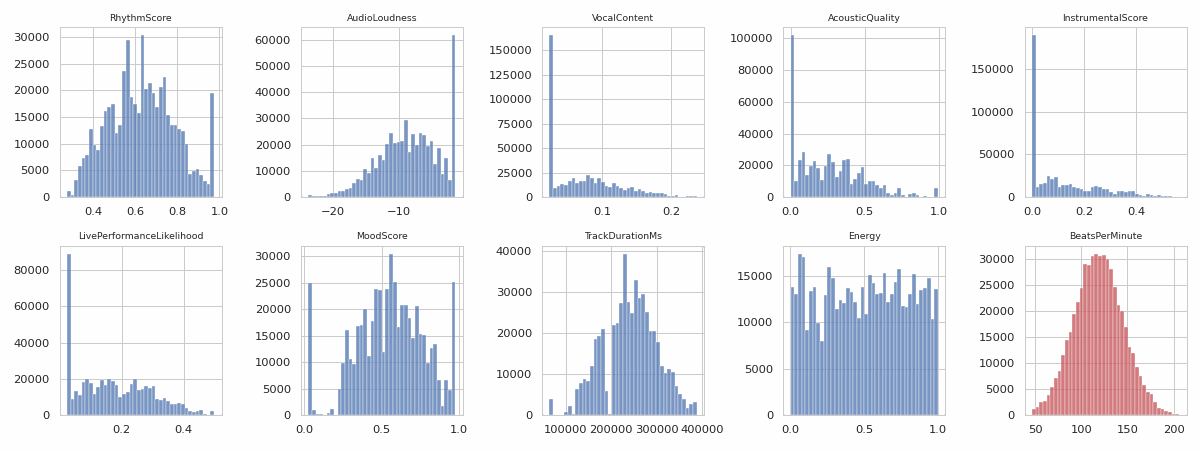

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(16, 6))
for ax, c in zip(axes.ravel(), FEATS + [TARGET]):
    sns.histplot(clean_tr[c], bins=40, ax=ax, color="#4c72b0" if c != TARGET else "#c44e52")
    ax.set_title(c, fontsize=9); ax.set_xlabel(""); ax.set_ylabel("")
savefig("01_distributions")

## 5. EDA: relationship with BPM

Energy                      -0.0034
AudioLoudness               -0.0024
AcousticQuality             -0.0001
InstrumentalScore            0.0026
VocalContent                 0.0036
LivePerformanceLikelihood    0.0044
RhythmScore                  0.0059
MoodScore                    0.0067
TrackDurationMs              0.0069
Name: BeatsPerMinute, dtype: float64


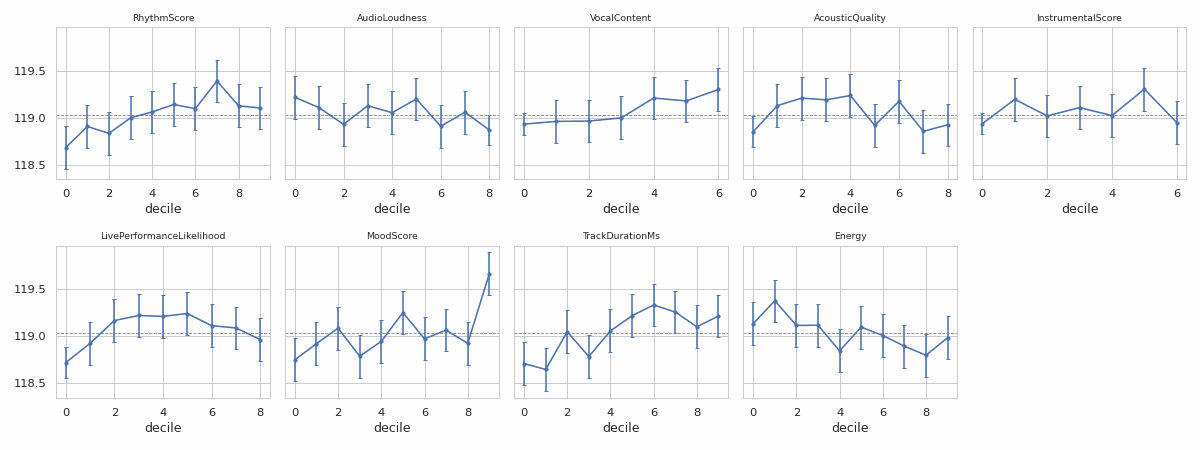

In [5]:
fig, axes = plt.subplots(2, 5, figsize=(16, 6), sharey=True)
for ax, c in zip(axes.ravel(), FEATS):
    b = pd.qcut(clean_tr[c], 10, duplicates="drop")
    g = clean_tr.groupby(b, observed=True)[TARGET].agg(["mean", "std", "count"])
    ci = 1.96 * g["std"] / np.sqrt(g["count"])
    ax.errorbar(range(len(g)), g["mean"], yerr=ci, fmt="o-", ms=3, capsize=2)
    ax.axhline(clean_tr[TARGET].mean(), color="grey", ls="--", lw=.8)
    ax.set_title(c, fontsize=9); ax.set_xlabel("decile")
axes.ravel()[-1].axis("off")
savefig("02_bpm_vs_features_deciles")
print(clean_tr[FEATS + [TARGET]].corr(method="spearman")[TARGET].drop(TARGET).round(4).sort_values())

**Insight:** mean BPM is flat across the deciles of every feature (all Spearman |ρ| < 0.01), so the raw features carry almost no signal.

## 6. Feature engineering

In [6]:
AUDIO01 = ["RhythmScore", "VocalContent", "AcousticQuality", "InstrumentalScore",
           "LivePerformanceLikelihood", "MoodScore", "Energy"]
dur_edges = clean_tr["TrackDurationMs"].quantile([0, .2, .4, .6, .8, 1]).values
loud_edges = clean_tr["AudioLoudness"].quantile([0, .2, .4, .6, .8, 1]).values
def engineer(df):
    d = df[FEATS].copy()
    d["Duration_min"] = d["TrackDurationMs"] / 60000
    d["Duration_log"] = np.log1p(d["TrackDurationMs"])
    d["Duration_band"] = np.clip(np.digitize(d["TrackDurationMs"], dur_edges[1:-1]), 0, 4)
    d["Loudness_band"] = np.clip(np.digitize(d["AudioLoudness"], loud_edges[1:-1]), 0, 4)
    d["Rhythm_x_Energy"] = d["RhythmScore"] * d["Energy"]
    d["Loudness_x_Energy"] = d["AudioLoudness"] * d["Energy"]
    d["Mood_x_Energy"] = d["MoodScore"] * d["Energy"]
    d["Vocal_plus_Instr"] = d["VocalContent"] + d["InstrumentalScore"]
    d["Acoustic_minus_Energy"] = d["AcousticQuality"] - d["Energy"]
    d["Live_x_Vocal"] = d["LivePerformanceLikelihood"] * d["VocalContent"]
    d["Energy_to_Acoustic"] = d["Energy"] / (d["AcousticQuality"] + 1e-3)
    d["Loudness_per_min"] = d["AudioLoudness"] / d["Duration_min"]
    d["Audio_mean"] = d[AUDIO01].mean(axis=1)
    d["Audio_std"] = d[AUDIO01].std(axis=1)
    d["Audio_max"] = d[AUDIO01].max(axis=1)
    d["Audio_min"] = d[AUDIO01].min(axis=1)
    return d.astype("float32")
X_all, X_test = engineer(clean_tr), engineer(clean_te)
y_all = clean_tr[TARGET].values
NEW = [c for c in X_all.columns if c not in FEATS]
print(f"{len(FEATS)} raw -> {X_all.shape[1]} features ({len(NEW)} engineered)")
print("\nSpearman corr with BPM (engineered):")
print(X_all[NEW].corrwith(pd.Series(y_all, index=X_all.index), method="spearman").round(4).sort_values().to_string())

9 raw -> 25 features (16 engineered)

Spearman corr with BPM (engineered):
Loudness_band           -0.0027
Energy_to_Acoustic      -0.0022
Rhythm_x_Energy         -0.0009
Loudness_x_Energy        0.0005
Mood_x_Energy            0.0005
Loudness_per_min         0.0006
Acoustic_minus_Energy    0.0021
Audio_std                0.0025
Vocal_plus_Instr         0.0038
Audio_min                0.0049
Audio_max                0.0049
Audio_mean               0.0060
Duration_log             0.0069
Duration_min             0.0069
Duration_band            0.0069
Live_x_Vocal             0.0072


**Feature engineering notes (16 new features):**
- Duration in minutes, log duration, and a quantile duration band
- Loudness quantile band
- Interactions: Rhythm×Energy, Loudness×Energy, Mood×Energy, Live×Vocal
- Vocal+Instrumental, Acoustic−Energy, Energy/Acoustic ratio, Loudness per minute
- Row-wise mean/std/max/min of the seven 0–1 audio scores

Band edges are fitted on train only.

## 7. Correlations

Highest |corr| with BPM:
 TrackDurationMs    0.0094
Duration_min       0.0094
Duration_log       0.0091
Duration_band      0.0091
Loudness_band      0.0077


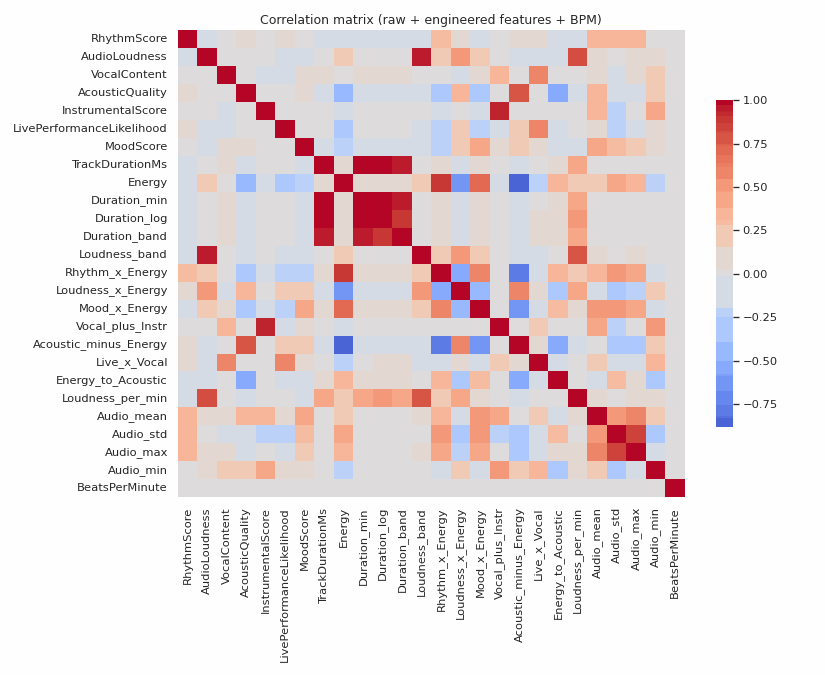

In [7]:
plt.figure(figsize=(11, 9))
c = pd.concat([X_all, pd.Series(y_all, name=TARGET, index=X_all.index)], axis=1).sample(100000, random_state=SEED).corr()
sns.heatmap(c, cmap="coolwarm", center=0, annot=False, cbar_kws={"shrink": .7})
plt.title("Correlation matrix (raw + engineered features + BPM)")
savefig("03_correlation_heatmap")
print("Highest |corr| with BPM:\n", c[TARGET].drop(TARGET).abs().sort_values(ascending=False).head(5).round(4).to_string())

## 8. Train/validation split and scaling

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
idx_tr, idx_va = train_test_split(np.arange(len(X_all)), test_size=0.2, random_state=SEED)
Xtr_raw, Xva_raw = clean_tr.loc[idx_tr, FEATS], clean_tr.loc[idx_va, FEATS]
Xtr, Xva = X_all.iloc[idx_tr], X_all.iloc[idx_va]
ytr, yva = y_all[idx_tr], y_all[idx_va]
scaler = StandardScaler().fit(Xtr)
print("train/val:", Xtr.shape, Xva.shape, "| BPM mean train/val:", ytr.mean().round(2), yva.mean().round(2))

train/val: (419331, 25) (104833, 25) | BPM mean train/val: 119.06 118.95


## 9. Baseline models (validation RMSE)

In [9]:
from sklearn.linear_model import Ridge
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error
rmse = lambda a, b: mean_squared_error(a, b) ** 0.5
res = {"Mean baseline": rmse(yva, np.full_like(yva, ytr.mean()))}
sc_raw = StandardScaler().fit(Xtr_raw)
res["Ridge (raw, scaled)"] = rmse(yva, Ridge(1.0).fit(sc_raw.transform(Xtr_raw), ytr).predict(sc_raw.transform(Xva_raw)))
res["Ridge (engineered, scaled)"] = rmse(yva, Ridge(1.0).fit(scaler.transform(Xtr), ytr).predict(scaler.transform(Xva)))
hgb = dict(max_iter=300, learning_rate=0.05, max_leaf_nodes=15, min_samples_leaf=200,
           early_stopping=True, validation_fraction=0.1, random_state=SEED)
res["HistGB (raw)"] = rmse(yva, HistGradientBoostingRegressor(**hgb).fit(Xtr_raw, ytr).predict(Xva_raw))
model = HistGradientBoostingRegressor(**hgb).fit(Xtr, ytr)
res["HistGB (engineered)"] = rmse(yva, model.predict(Xva))
print(pd.Series(res).round(4).rename("validation RMSE").to_string())

Mean baseline                 26.4454
Ridge (raw, scaled)           26.4439
Ridge (engineered, scaled)    26.4439
HistGB (raw)                  26.4385
HistGB (engineered)           26.4393


Engineered features did not improve RMSE beyond noise (about 0.01 from the mean baseline).

## 10. Feature importance

MoodScore             0.0175
TrackDurationMs       0.0038
RhythmScore           0.0031
Energy_to_Acoustic    0.0020
Mood_x_Energy         0.0009
VocalContent          0.0008
Live_x_Vocal          0.0008
Vocal_plus_Instr      0.0005


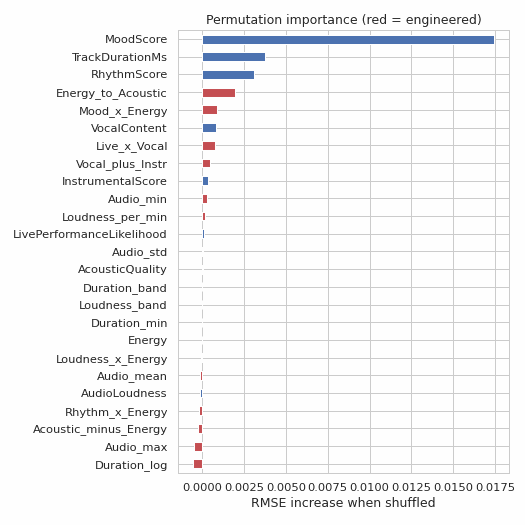

In [10]:
from sklearn.inspection import permutation_importance
sub = np.random.RandomState(SEED).choice(len(Xva), 40000, replace=False)
pi = permutation_importance(model, Xva.iloc[sub], yva[sub], scoring="neg_root_mean_squared_error",
                            n_repeats=3, random_state=SEED, n_jobs=-1)
imp = pd.Series(pi.importances_mean, index=Xva.columns).sort_values()
plt.figure(figsize=(7, 7))
imp.plot.barh(color=["#c44e52" if i in NEW else "#4c72b0" for i in imp.index])
plt.xlabel("RMSE increase when shuffled"); plt.title("Permutation importance (red = engineered)")
savefig("04_permutation_importance")
print(imp.sort_values(ascending=False).head(8).round(4).to_string())

**Highlight:** `MoodScore` is the strongest (weak) signal, followed by `TrackDurationMs` and `RhythmScore`.

## 11. Save cleaned data (sample)

In [11]:
FULL_EXPORT = False
out_cols = [*X_all.columns]
sample = X_all.assign(**{TARGET: y_all.astype("float32")}).sample(5000, random_state=SEED).round(4)
sample.to_csv("cleaned_train_sample.csv.gz", index=False)
print("saved cleaned_train_sample.csv.gz:", sample.shape, os.path.getsize("cleaned_train_sample.csv.gz") // 1024, "KB")
if FULL_EXPORT:
    X_all.assign(**{TARGET: y_all}).to_csv("cleaned_train_full.csv.gz", index=False)
    X_test.assign(id=test["id"].values).to_csv("cleaned_test_full.csv.gz", index=False)

saved cleaned_train_sample.csv.gz: (5000, 26) 340 KB
